In [120]:
import pandas as pd

In [121]:
df=pd.read_csv('penguins_size.csv')

In [122]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [124]:
df.isnull().sum().sort_values(ascending=False)

sex                  10
culmen_depth_mm       2
culmen_length_mm      2
flipper_length_mm     2
body_mass_g           2
island                0
species               0
dtype: int64

In [125]:
for col in df.columns:
    if df[col].isnull().sum()>=1:
        if df[col].dtype=='object':
            df[col].fillna(df[col].mode()[0],inplace=True)
        else:
            df[col].fillna(df[col].mean(),inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_10864\615579166.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_10864\615579166.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

In [126]:
df.isnull().sum().sort_values(ascending=False)

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

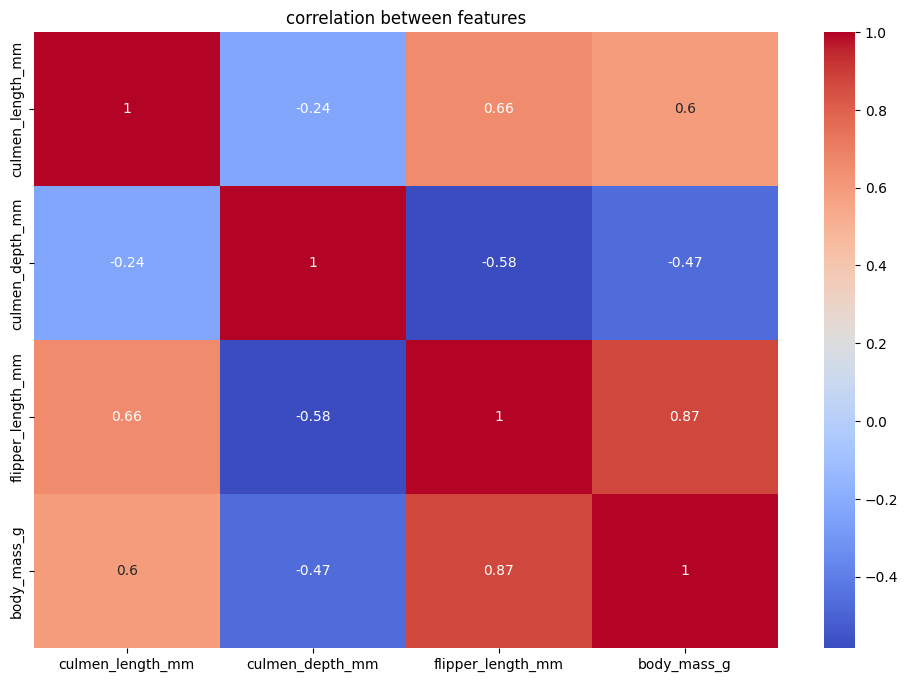

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('correlation between features')
plt.show()

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   344 non-null    float64
 3   culmen_depth_mm    344 non-null    float64
 4   flipper_length_mm  344 non-null    float64
 5   body_mass_g        344 non-null    float64
 6   sex                344 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [129]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=label.fit_transform(df[col])
        

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    int64  
 1   island             344 non-null    int64  
 2   culmen_length_mm   344 non-null    float64
 3   culmen_depth_mm    344 non-null    float64
 4   flipper_length_mm  344 non-null    float64
 5   body_mass_g        344 non-null    float64
 6   sex                344 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 18.9 KB


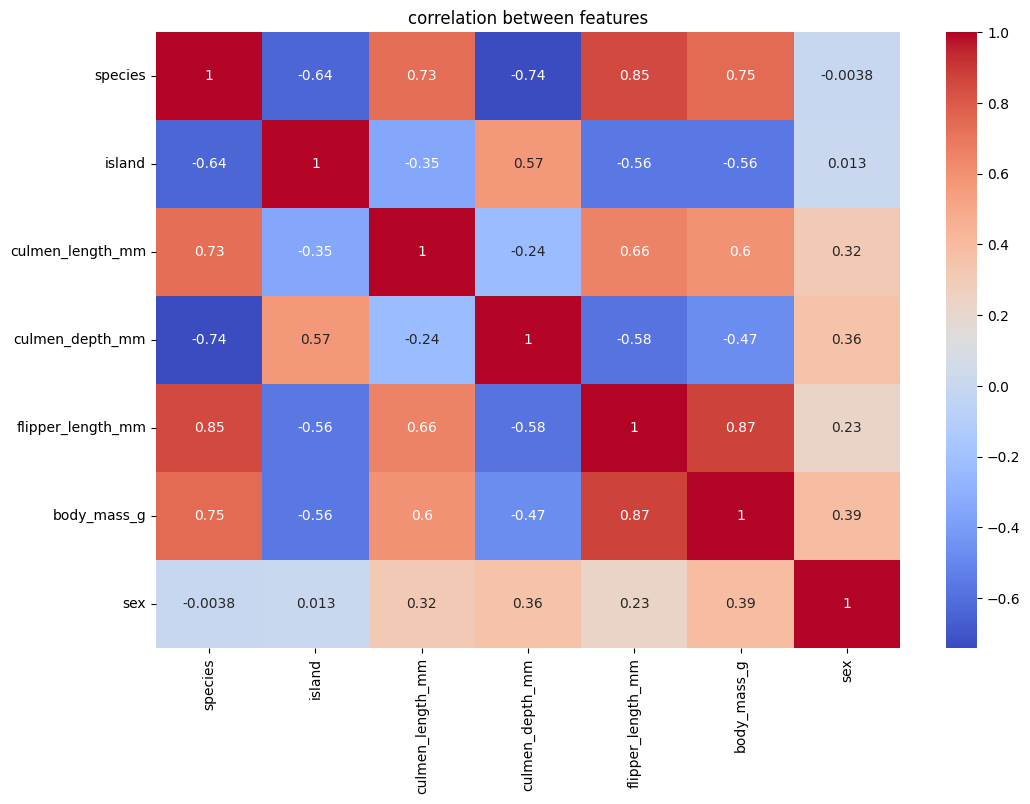

In [131]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('correlation between features')
plt.show()

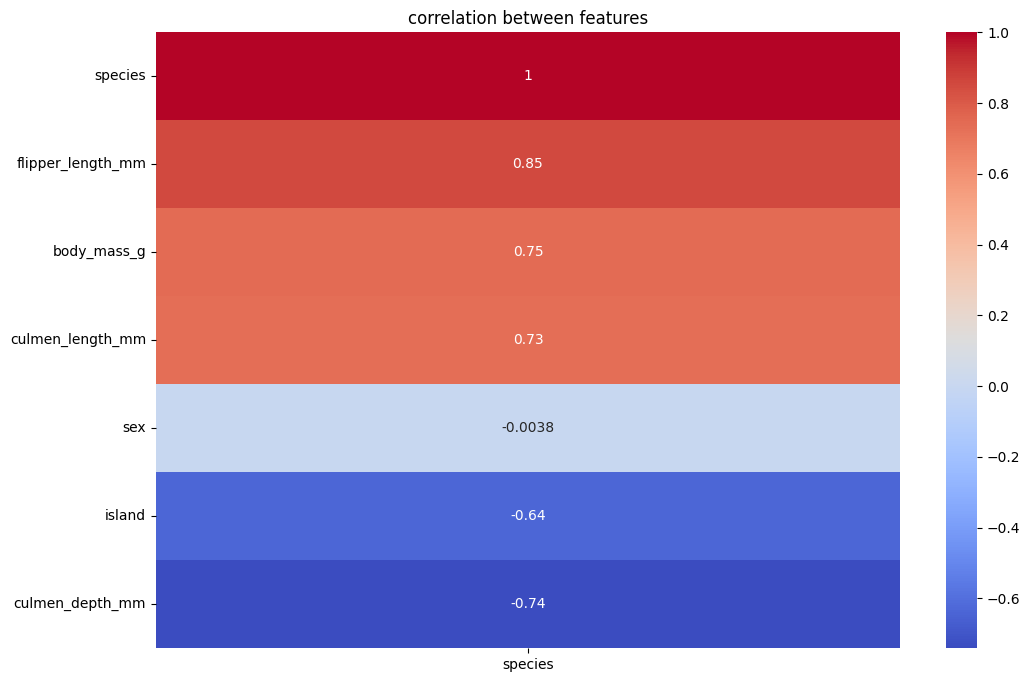

In [132]:
corr=df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr[['species']].sort_values(by = 'species',ascending = False),annot=True,cmap='coolwarm')
plt.title('correlation between features')
plt.show()

In [133]:
X=df.drop('species',axis=1)
y=df['species']

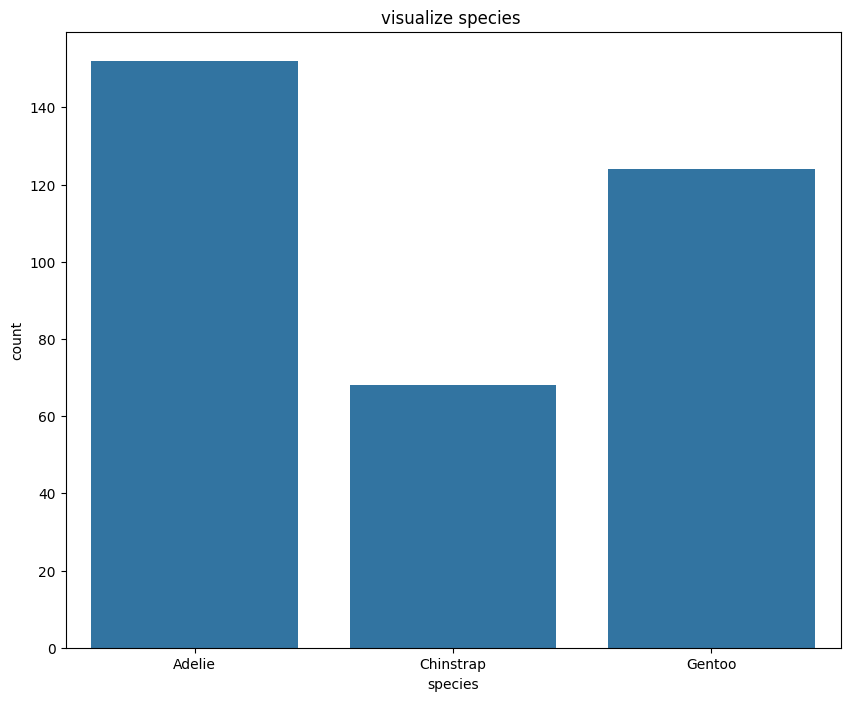

In [134]:
plt.figure(figsize=(10,8))
sns.countplot(x=y)
plt.title("visualize species ")
plt.xticks([0,1,2],['Adelie','Chinstrap','Gentoo'])
plt.show()
#this exist some inbalance we will try smote later

In [135]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

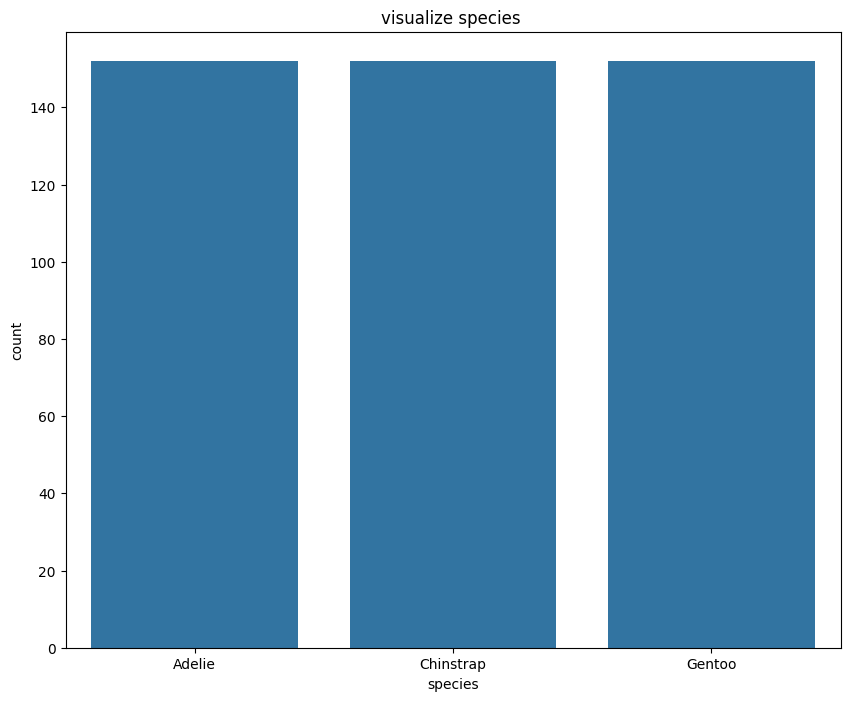

In [136]:
plt.figure(figsize=(10,8))
sns.countplot(x=y_resampled)
plt.title("visualize species ")
plt.xticks([0,1,2],['Adelie','Chinstrap','Gentoo'])
plt.show()

In [137]:
X=X_resampled
y=y_resampled

In [138]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_scaled=scale.fit_transform(X)


In [139]:
from sklearn.model_selection import  train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,stratify=y)

In [140]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
models={
       'SVM':SVC(),
    'knn':KNeighborsClassifier(),
    'logstic regression':LogisticRegression(),
    'ID3':DecisionTreeClassifier(),
    'random forest':RandomForestClassifier(),
    'XG_boost':XGBClassifier()
}

In [141]:
from sklearn.model_selection import cross_val_score
result=[]
for mode_n,model_per in models.items():
    test=cross_val_score(model_per,X_scaled,y,cv=5,scoring='accuracy')
    result.append({'model_name':mode_n,'score':test.mean()})
sh=pd.DataFrame(result)
print(sh)

           model_name     score
0                 SVM  0.993407
1                 knn  0.991233
2  logstic regression  0.995604
3                 ID3  0.975872
4       random forest  0.986837
5            XG_boost  0.984639


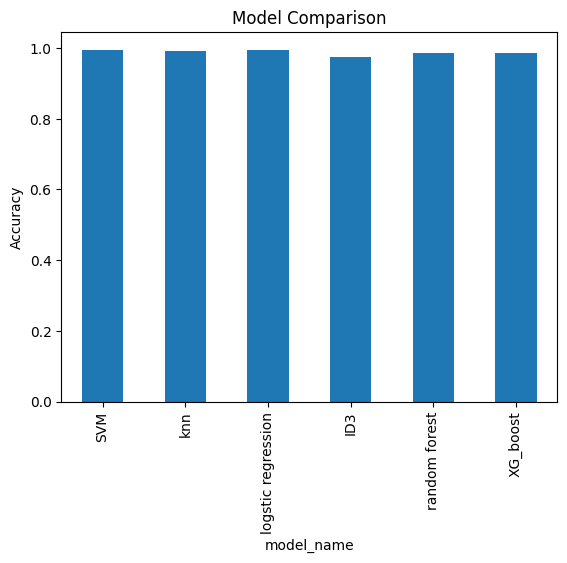

In [142]:

sh.plot(x='model_name', y='score', kind='bar', legend=False)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

# SVM

In [143]:
from sklearn.model_selection import  GridSearchCV
md=SVC(random_state=42)
param={
    'kernel':['poly','rbf','linear'],
    'C':[1,10,100]
}
grid_search=GridSearchCV(
    estimator=md,
    scoring='accuracy',
    param_grid=param,
    cv=5
)
grid_search.fit(X_train,y_train)
print('Best parameters',grid_search.best_params_)
print('Best score',grid_search.best_score_)


Best parameters {'C': 1, 'kernel': 'rbf'}
Best score 1.0


# evaluation

accuracy 0.9782608695652174
confusion matrix <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x00000241A4EFAC50>
classifcation report                precision    recall  f1-score   support

           0       1.00      0.97      0.98        30
           1       0.94      1.00      0.97        31
           2       1.00      0.97      0.98        31

    accuracy                           0.98        92
   macro avg       0.98      0.98      0.98        92
weighted avg       0.98      0.98      0.98        92



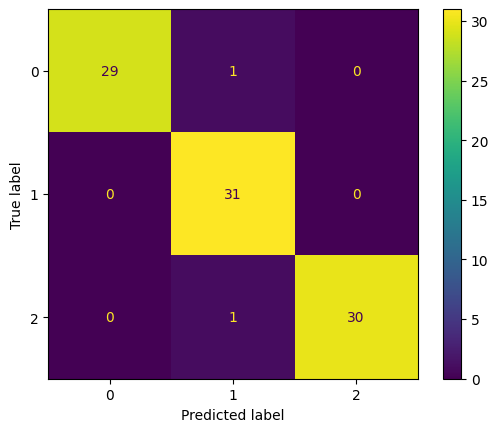

In [144]:
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay
mod=SVC(kernel='poly',C=1, probability=True, random_state=42)
mod.fit(X_train,y_train)
y_pred=mod.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy",accuracy)
print("confusion matrix",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print("classifcation report ",classification_report(y_test,y_pred))

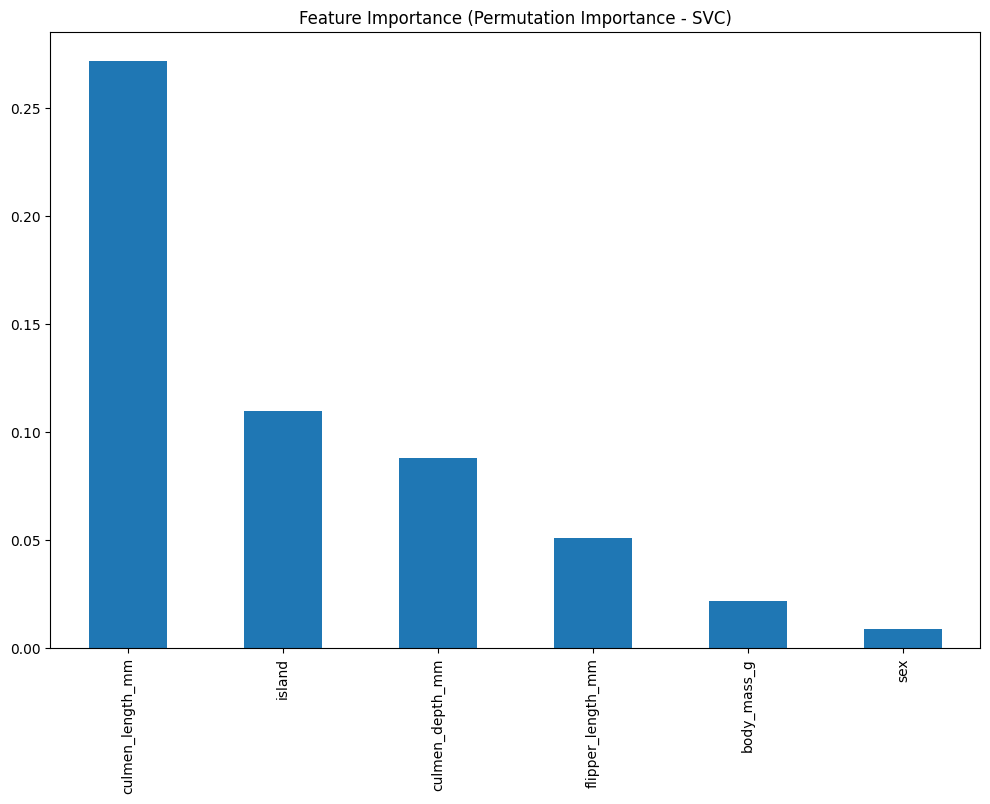

In [145]:
# لسه تتزاكر 
from sklearn.inspection import permutation_importance
result = permutation_importance(mod, X_test, y_test, n_repeats=10, random_state=42)
feature_importances = pd.Series(result.importances_mean, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12,8))
feature_importances.plot(kind='bar')
plt.title("Feature Importance (Permutation Importance - SVC)")
plt.show()

# ID3

In [146]:
md2 = DecisionTreeClassifier()
par={
'criterion':["gini", "entropy"],
'max_depth':[None, 3, 5, 10, 20],
'min_samples_split':[2, 5, 10, 20],
'min_samples_leaf':[1, 2, 4, 10],
'max_features':[None, "sqrt", "log2"]
}
grid=GridSearchCV(
    estimator=md2,
    scoring='accuracy',
    cv=5,
    param_grid=par
)
grid.fit(X_train,y_train)
print("Best parameter",grid.best_params_)
print("Best score",grid.best_score_)

Best parameter {'criterion': 'entropy', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score 0.980745814307458


accuracy 0.9456521739130435
confusion matrix <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002419E75ED50>
classifcation report                precision    recall  f1-score   support

           0       0.90      0.93      0.92        30
           1       0.94      0.94      0.94        31
           2       1.00      0.97      0.98        31

    accuracy                           0.95        92
   macro avg       0.95      0.95      0.95        92
weighted avg       0.95      0.95      0.95        92



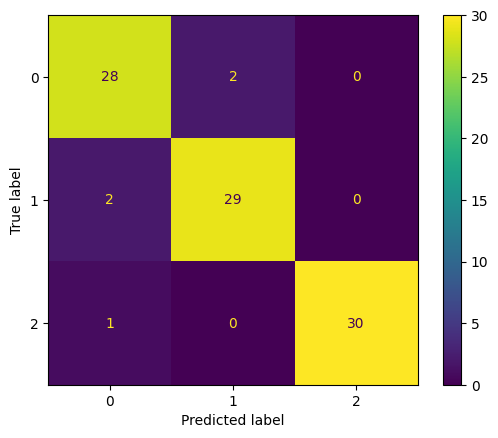

In [147]:
mod2=DecisionTreeClassifier(criterion='entropy',max_depth=20,max_features='log2',min_samples_leaf=1,min_samples_split=5)
mod2.fit(X_train,y_train)
y_pred=mod2.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy",accuracy)
print("confusion matrix",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print("classifcation report ",classification_report(y_test,y_pred))

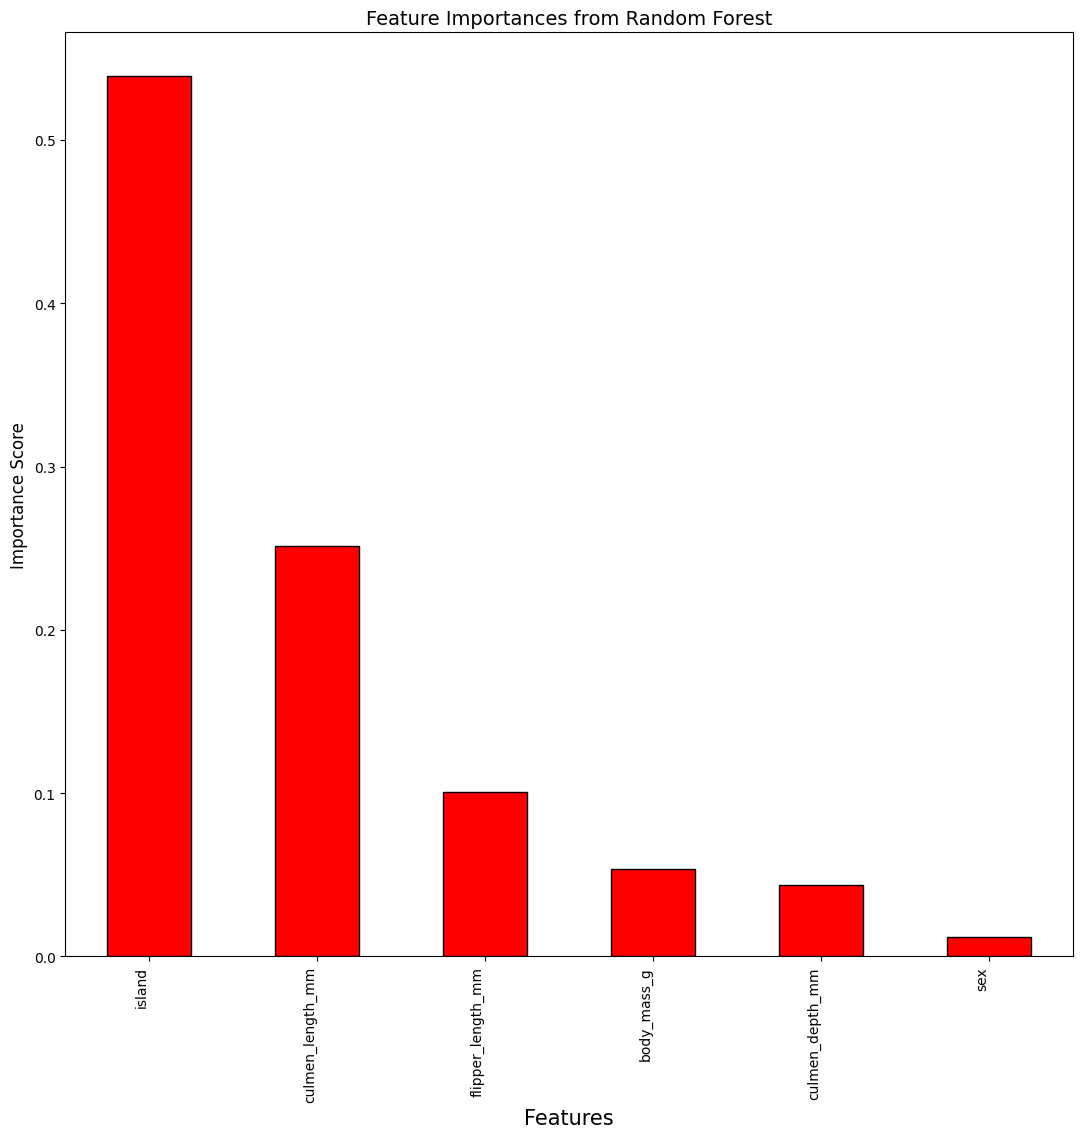

In [148]:
feature_importances = pd.Series(mod2.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(13,12))
feature_importances.plot(kind='bar', color='red', edgecolor='black')
plt.title("Feature Importances from Random Forest", fontsize=14)
plt.xlabel("Features", fontsize=15)
plt.ylabel("Importance Score", fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.show()

 # logstic regression 

In [149]:
md3=LogisticRegression(random_state=42)
param_grid = {
    'penalty': ['l1', 'l2'],   
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 500, 1000]
}

grid = GridSearchCV(
    estimator=md3,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 10, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 1.0


accuracy 0.9456521739130435
confusion matrix <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002419EC223D0>
classifcation report                precision    recall  f1-score   support

           0       0.90      0.93      0.92        30
           1       0.94      0.94      0.94        31
           2       1.00      0.97      0.98        31

    accuracy                           0.95        92
   macro avg       0.95      0.95      0.95        92
weighted avg       0.95      0.95      0.95        92



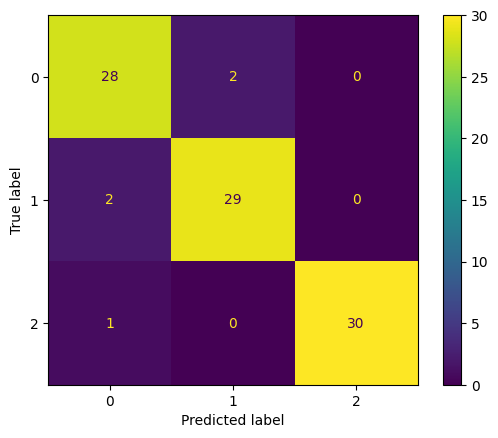

In [150]:
mod3=LogisticRegression(C=1,max_iter=100,penalty='l1',solver='liblinear',random_state=42)
mod3.fit(X_train,y_train)
y_pred=mod2.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy",accuracy)
print("confusion matrix",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print("classifcation report ",classification_report(y_test,y_pred))

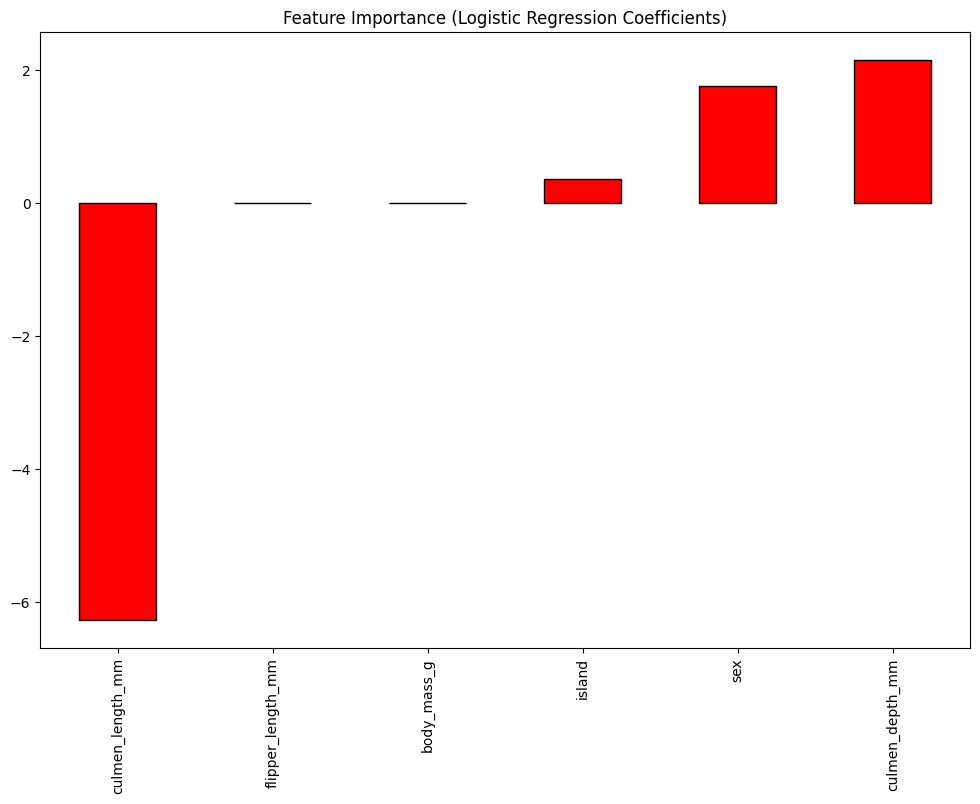

In [151]:
#لسه تتزاكر 
coefs = pd.Series(mod3.coef_[0], index=X.columns)
coefs = coefs.sort_values()

plt.figure(figsize=(12,8))
coefs.plot(kind='bar', color='red', edgecolor='black')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()